<a href="https://colab.research.google.com/github/RajanyaSaha-27/Cardio_Vascular_Prediction_and_Analysis/blob/main/Cardio_Vascular_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [ ]:
df=pd.read_csv("Heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [ ]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [ ]:
df.shape

(303, 14)

In [ ]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


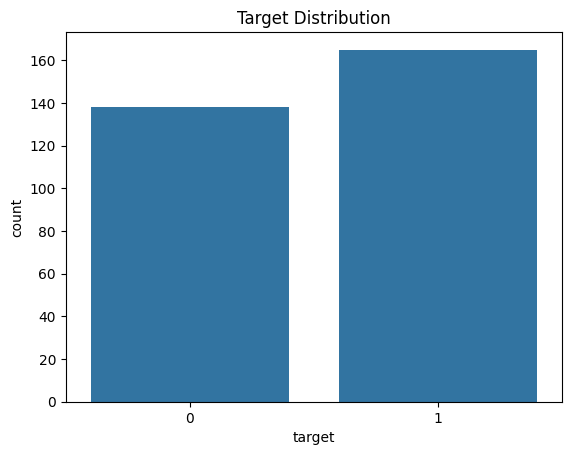

In [ ]:
sns.countplot(x='target',data=df)
plt.title("Target Distribution")
plt.show()

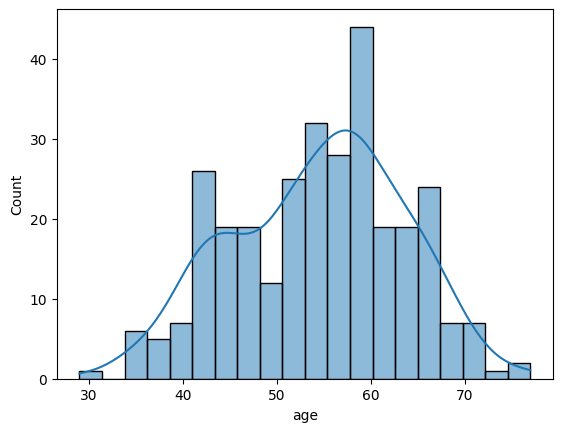

In [ ]:
#Age Distribution
sns.histplot(df['age'],bins=20,kde=True)
plt.show()

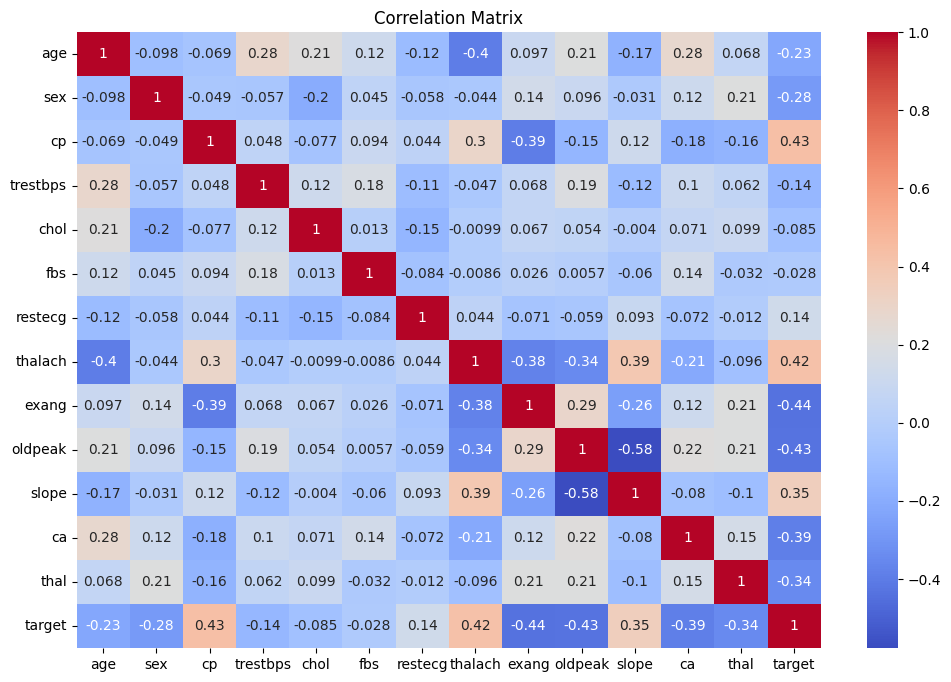

In [ ]:
#correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

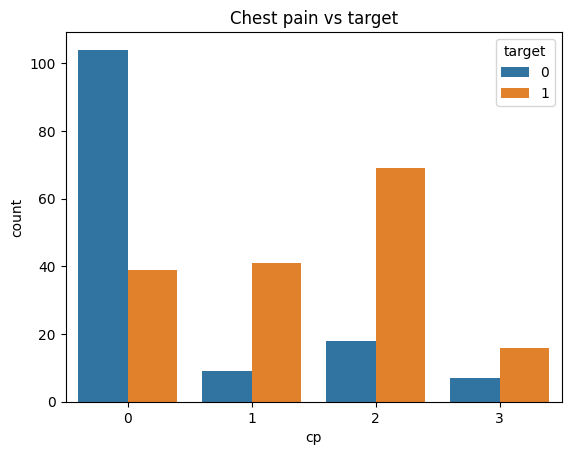

In [ ]:
#chest pain vs target
sns.countplot(x='cp',hue='target',data=df)
plt.title("Chest pain vs target")
plt.show()

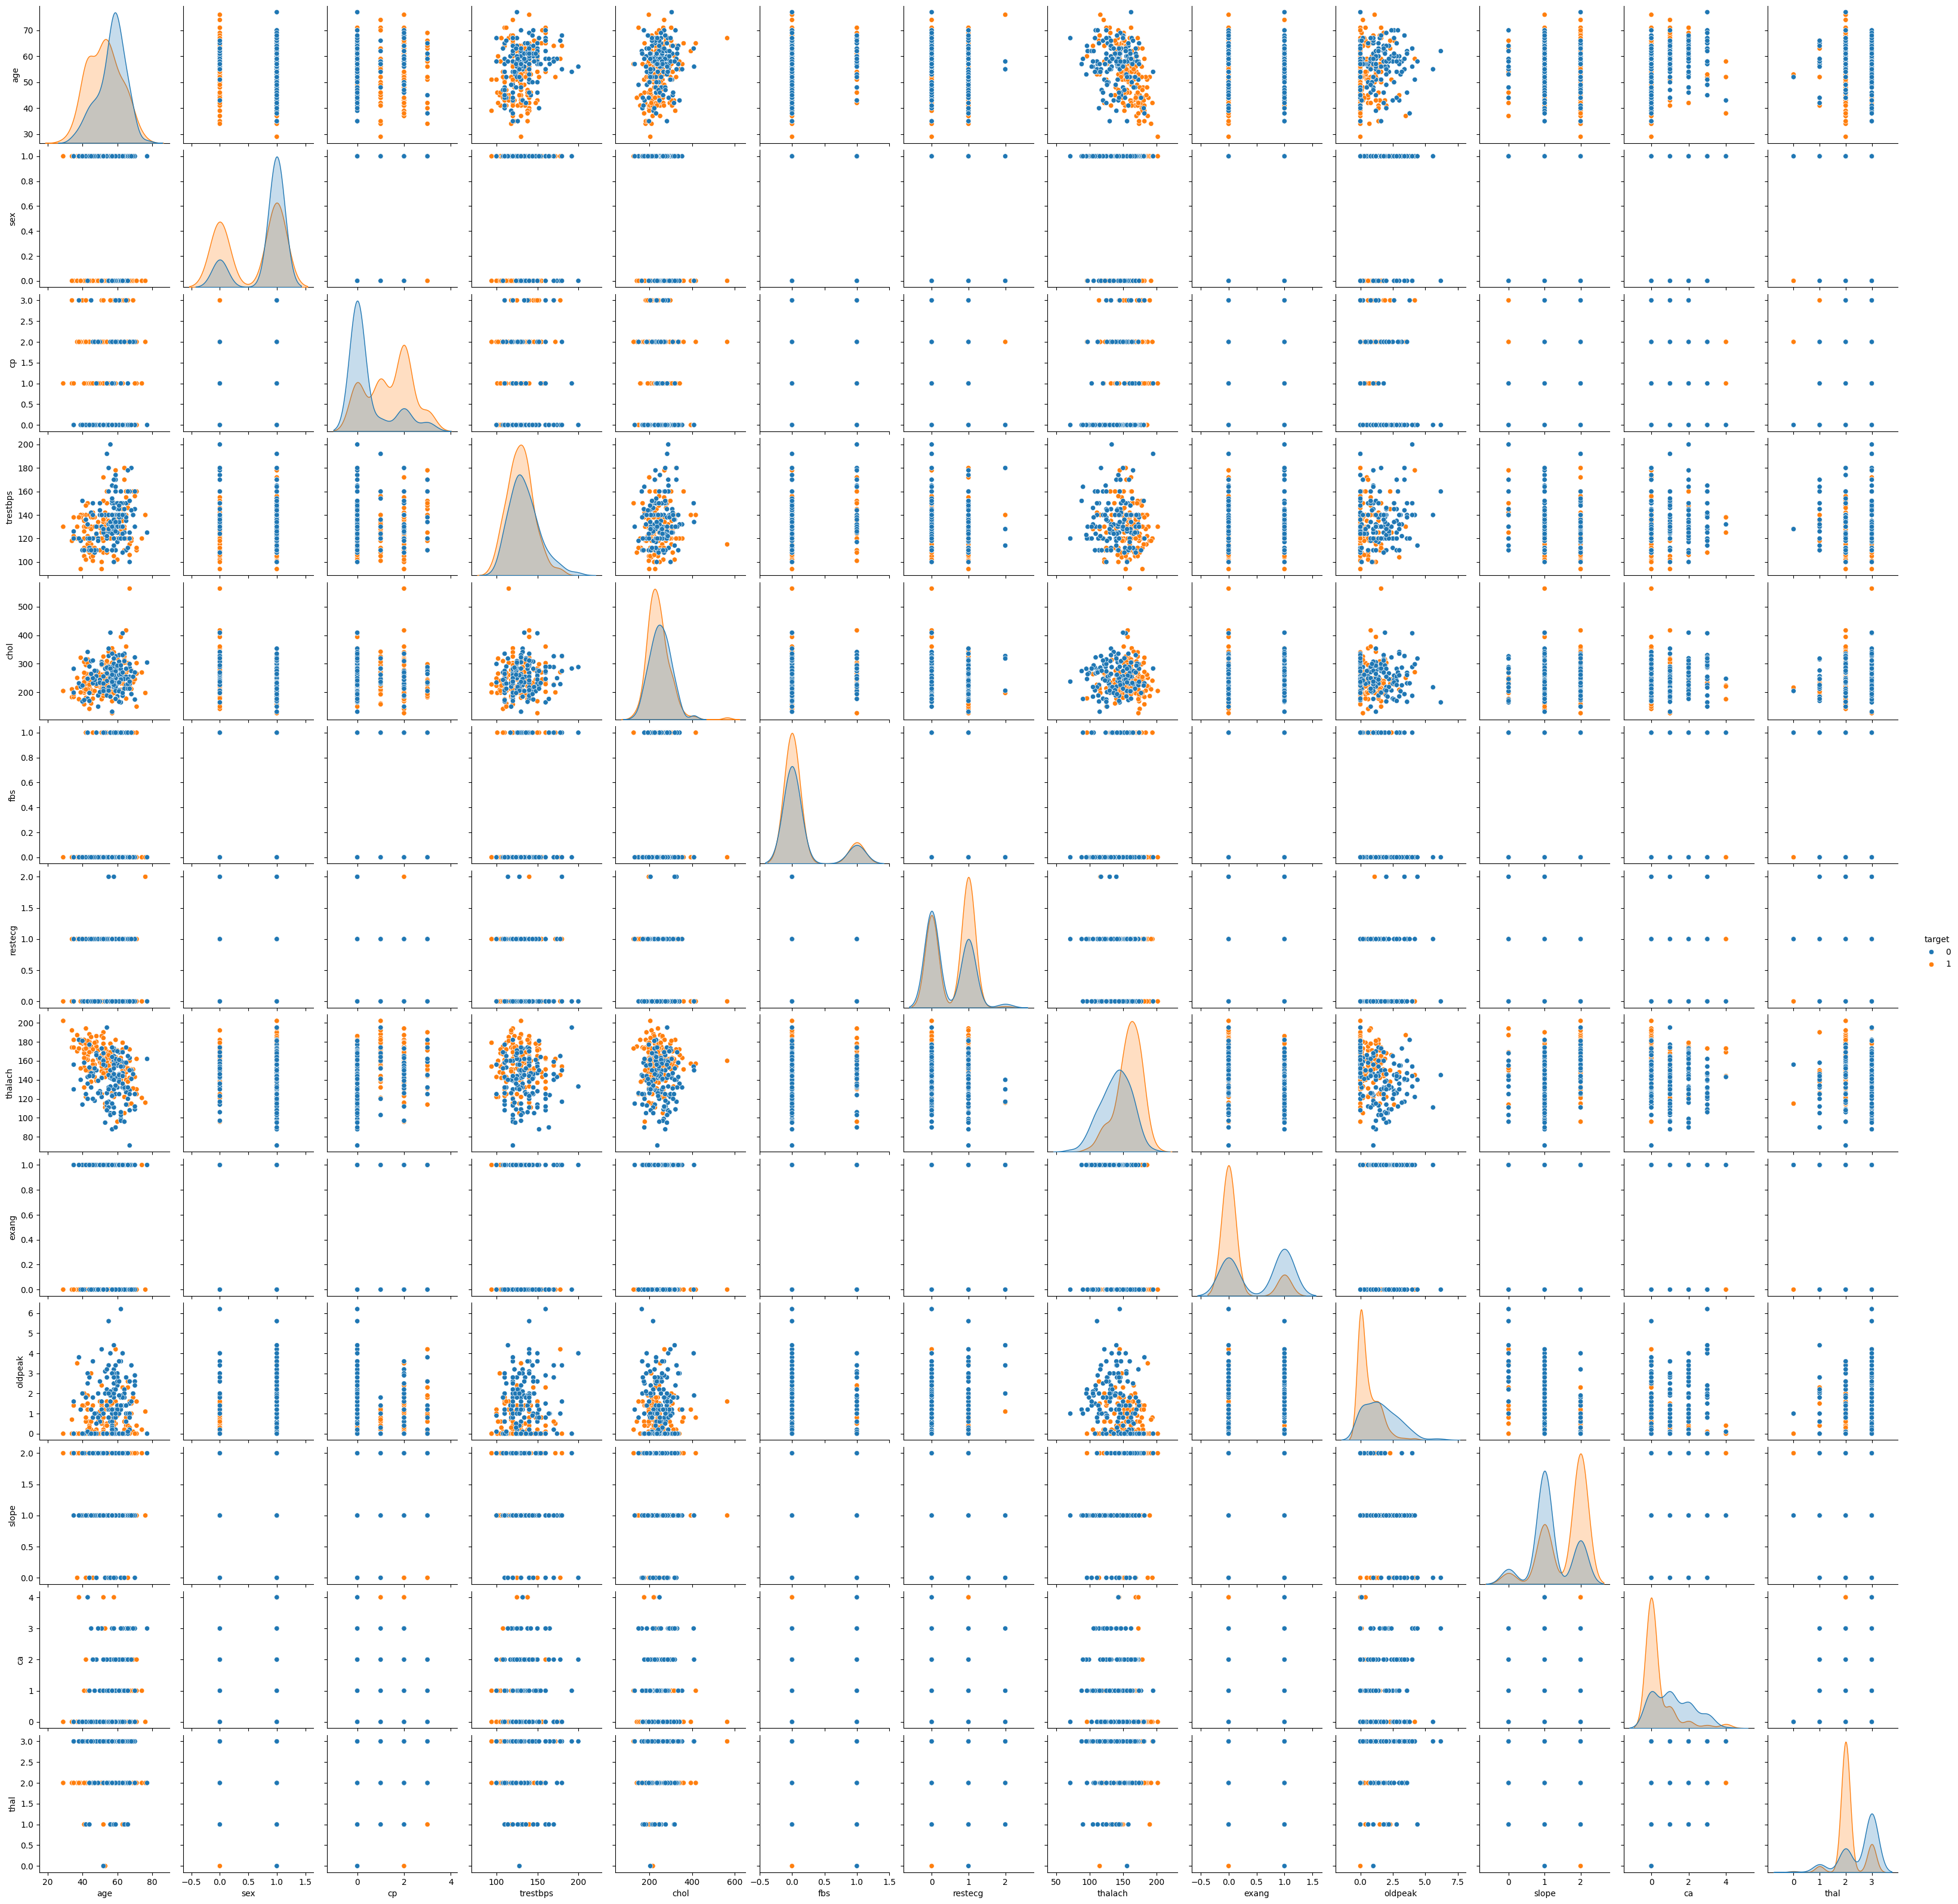

In [ ]:
#pairplot
sns.pairplot(df,hue='target')
plt.show()

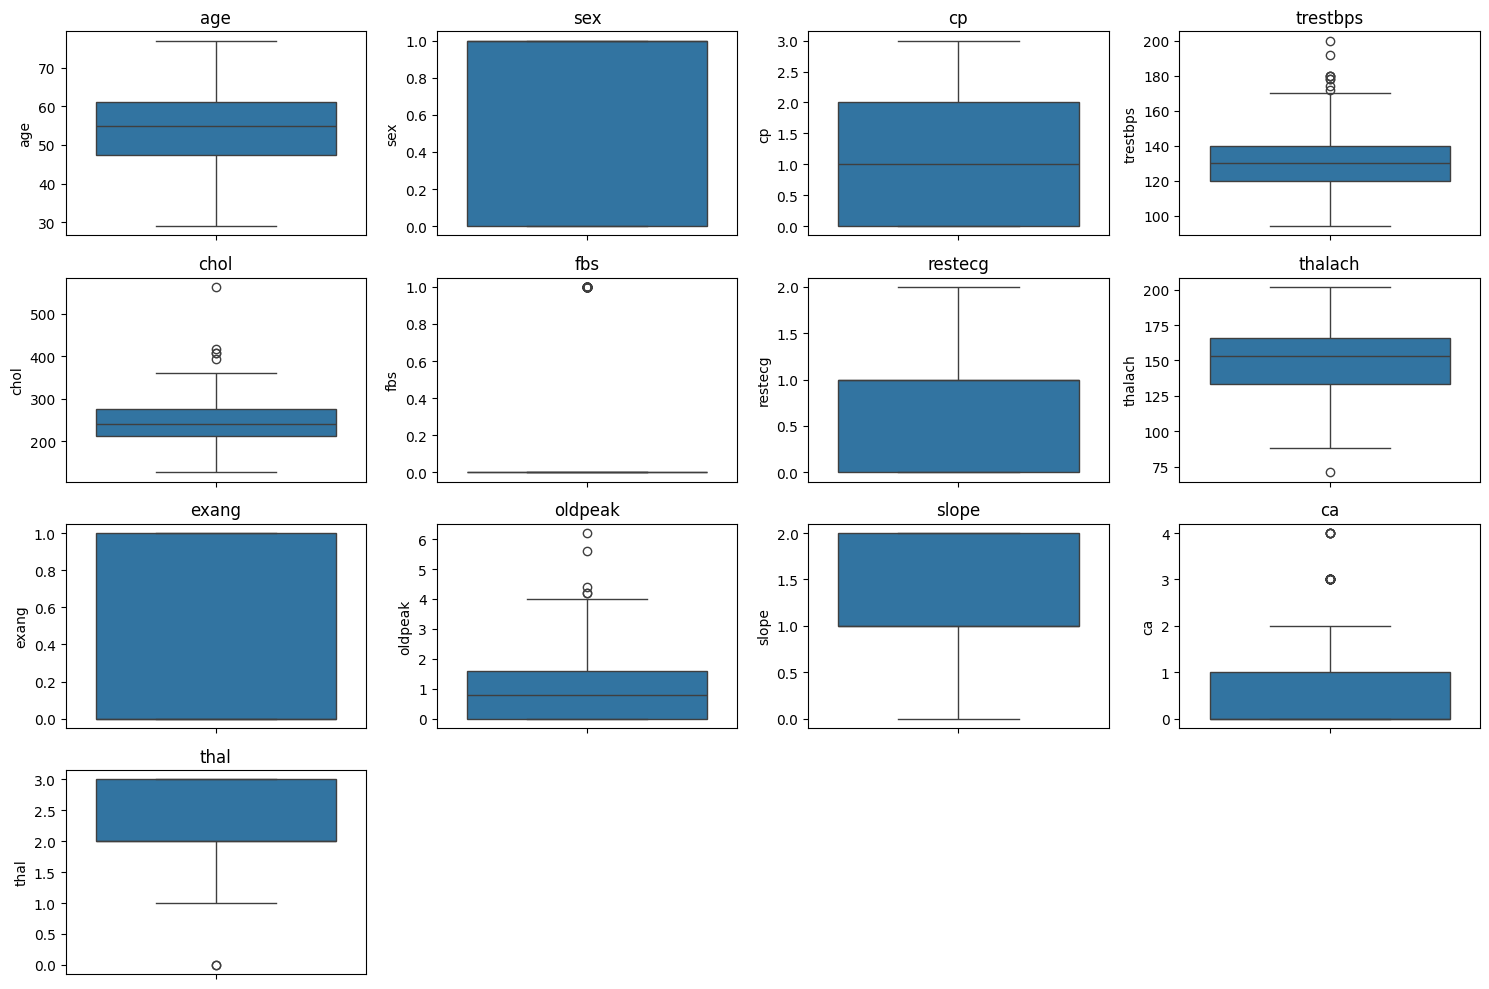

In [ ]:
#Outlier detection
plt.figure(figsize=(15,10))
for i,col in enumerate(df.columns[:-1],1):
  plt.subplot(4,4,i)
  sns.boxplot(y=df[col])
  plt.title(col)

plt.tight_layout()
plt.show()

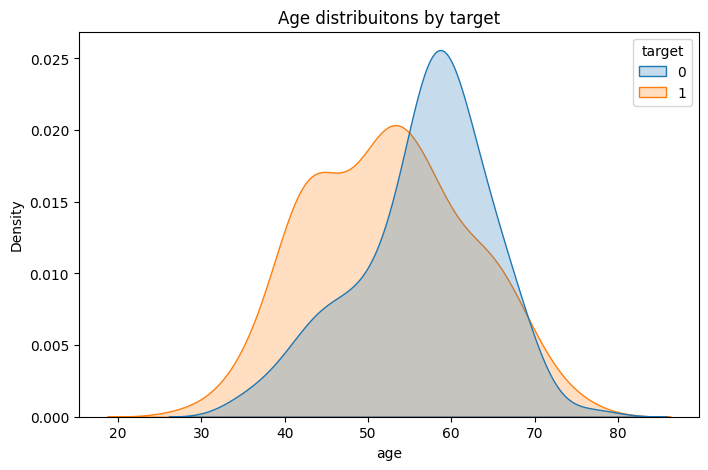

In [ ]:
#age vs target
plt.figure(figsize=(8,5))
sns.kdeplot(data=df,x='age',hue="target",fill=True)
plt.title("Age distribuitons by target")
plt.show()

In [ ]:
#import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("Heart.csv")

# Features and target
X = df.drop("target", axis=1)
y = df["target"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
#import matplotlib.pyplot as plt
#import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def plot_confusion_matrix(y_true, y_pred, model_name, cmap="Blues"):
    cm = confusion_matrix(y_true, y_pred)
    print(f"\n{model_name} Confusion Matrix:\n", cm)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap)
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

KNN Accuracy: 0.9016393442622951
              precision    recall  f1-score   support

           0       0.87      0.93      0.90        29
           1       0.93      0.88      0.90        32

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61


KNN Confusion Matrix:
 [[27  2]
 [ 4 28]]


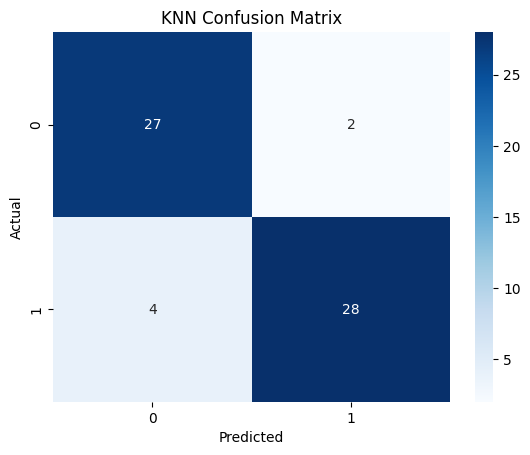

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Train KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

# Accuracy & Report
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

# Confusion Matrix
plot_confusion_matrix(y_test, y_pred_knn, "KNN", "Blues")

Decision Tree Accuracy: 0.8524590163934426
              precision    recall  f1-score   support

           0       0.81      0.90      0.85        29
           1       0.90      0.81      0.85        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.86      0.85      0.85        61


Decision Tree Confusion Matrix:
 [[26  3]
 [ 6 26]]


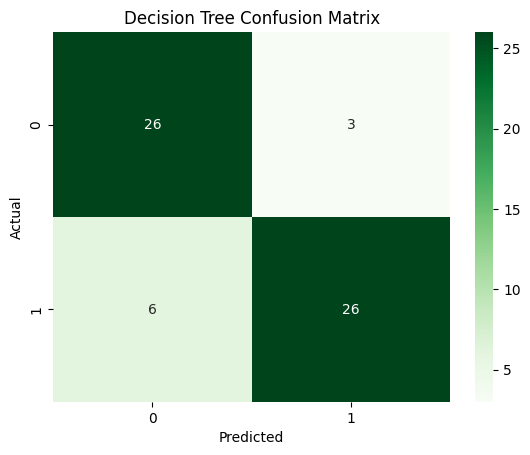

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Train Decision Tree
dtree = DecisionTreeClassifier(max_depth=4, random_state=42)
dtree.fit(X_train, y_train)
y_pred_tree = dtree.predict(X_test)

# Accuracy & Report
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))

# Confusion Matrix
plot_confusion_matrix(y_test, y_pred_tree, "Decision Tree", "Greens")

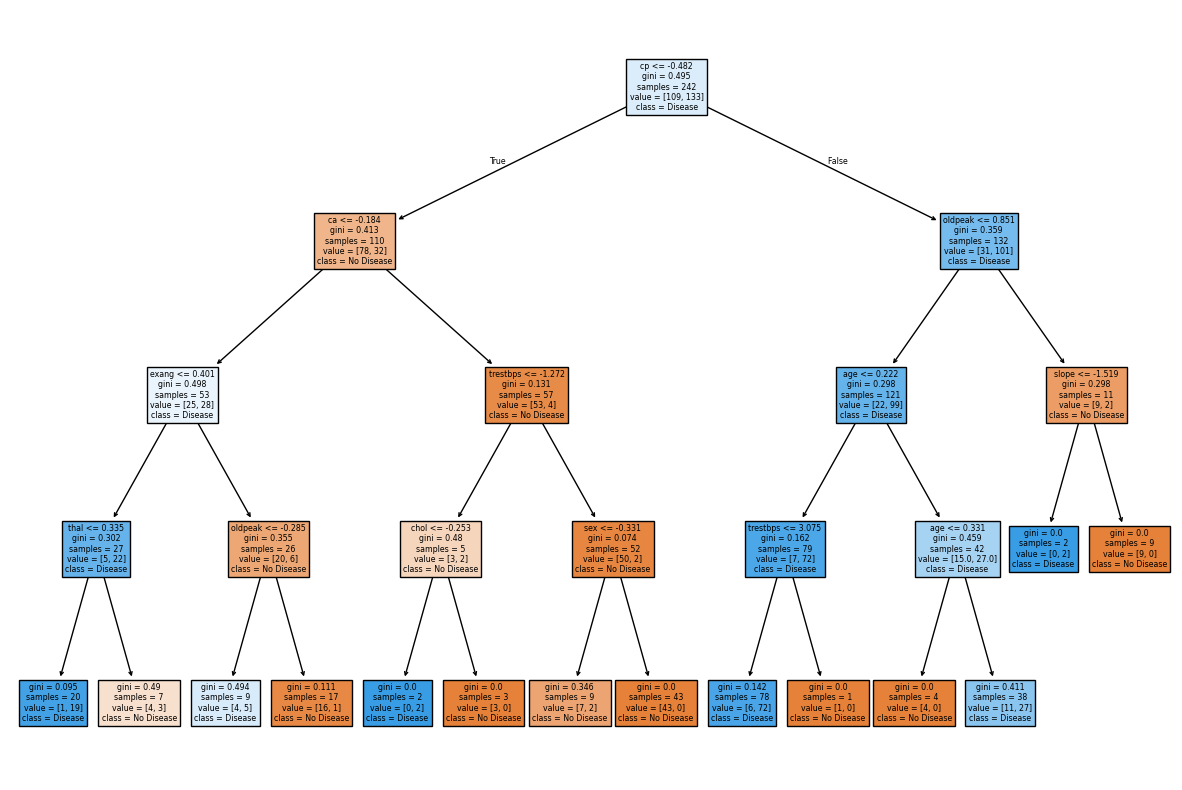

In [ ]:
plt.figure(figsize=(15,10))
plot_tree(dtree, feature_names=df.columns[:-1], class_names=["No Disease","Disease"], filled=True)
plt.show()

Random Forest Accuracy: 0.8688524590163934
              precision    recall  f1-score   support

           0       0.89      0.83      0.86        29
           1       0.85      0.91      0.88        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61


Random Forest Confusion Matrix:
 [[24  5]
 [ 3 29]]


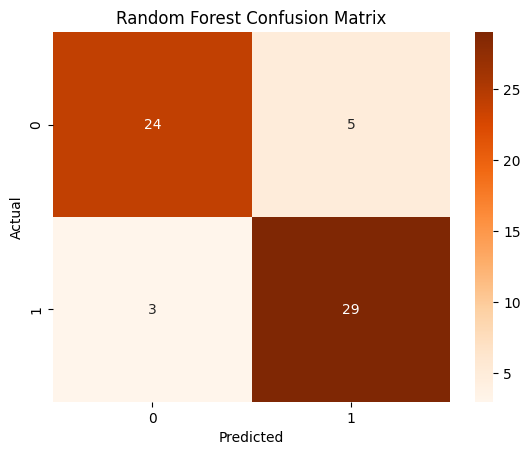

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Accuracy & Report
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
plot_confusion_matrix(y_test, y_pred_rf, "Random Forest", "Oranges")

/tmp/ipykernel_360/2854644989.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=df.columns[:-1][indices], palette="viridis")


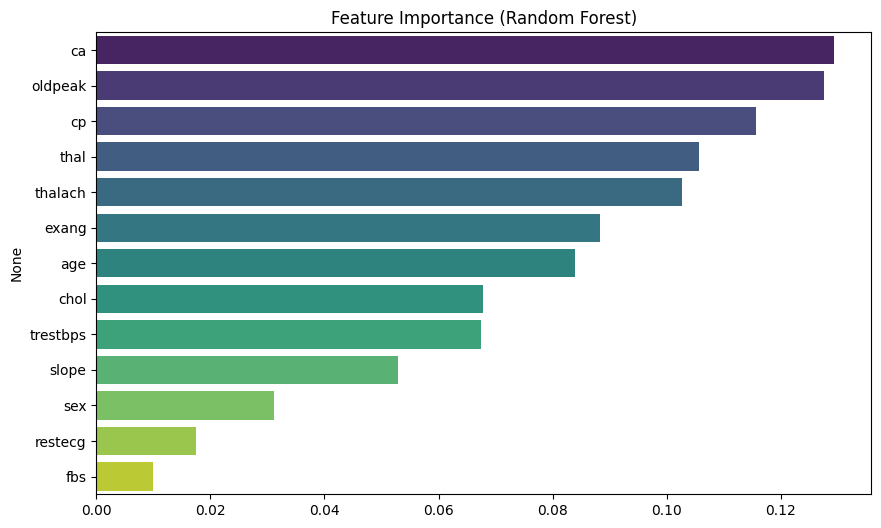

In [ ]:
importances = rf.feature_importances_
indices = importances.argsort()[::-1]

plt.figure(figsize=(10,6))
sns.barplot(x=importances[indices], y=df.columns[:-1][indices], palette="viridis")
plt.title("Feature Importance (Random Forest)")
plt.show()

In [ ]:
results = pd.DataFrame({
    "Model": ["KNN", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf)
    ]
})
print("\nModel Comparison:\n", results)


Model Comparison:
            Model  Accuracy
0            KNN  0.901639
1  Decision Tree  0.852459
2  Random Forest  0.868852
